# Feature Importance Analysis

## Objective

Identify the most influential features contributing to hospital readmission prediction.

## Reason

The final model uses PCA, which transforms original features into principal components. Therefore, direct feature importance cannot be extracted from the final model.

To estimate feature importance, a temporary Logistic Regression model will be trained on the scaled original features without PCA.

## Note

This analysis is only for understanding feature influence and designing the frontend.

The final project model remains:

StandardScaler
↓
PCA (95% Variance)
↓
Logistic Regression

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns



In [30]:
import joblib

X = joblib.load("cleaned_X.pkl")
y = joblib.load("cleaned_y.pkl")

print(X.shape)
print(y.shape)

(101766, 41)
(101766,)


In [31]:
import joblib

X = joblib.load("cleaned_X.pkl")
y = joblib.load("cleaned_y.pkl")

print(X.shape)
print(y.shape)

(101766, 41)
(101766,)


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)

Train shape: (81412, 41)


In [33]:
from sklearn.linear_model import LogisticRegression

lr_no_pca = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

lr_no_pca.fit(X_train_scaled, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [34]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr_no_pca.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
13,number_inpatient,0.368240
4,discharge_disposition_id,0.136156
17,number_diagnoses,0.082941
33,insulin,0.077014
2,age,0.066244
12,number_emergency,0.061953
6,time_in_hospital,0.061831
40,diabetesMed,0.058997
39,change,0.036420
18,metformin,0.034301


# Feature Importance Visualization

The following visualizations identify the most influential features used for frontend feature selection.

In [35]:
print(feature_importance.columns)

Index(['Feature', 'Importance'], dtype='str')


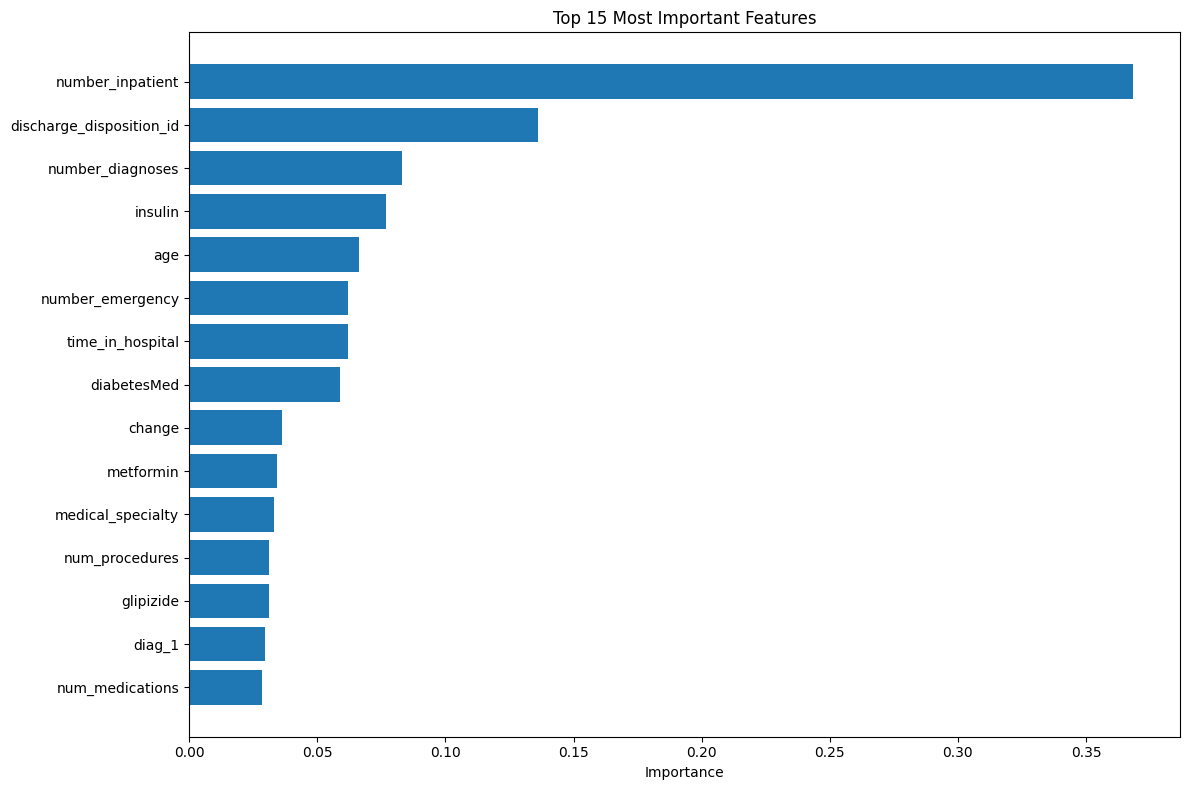

In [42]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12,8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()


<Figure size 1200x600 with 0 Axes>

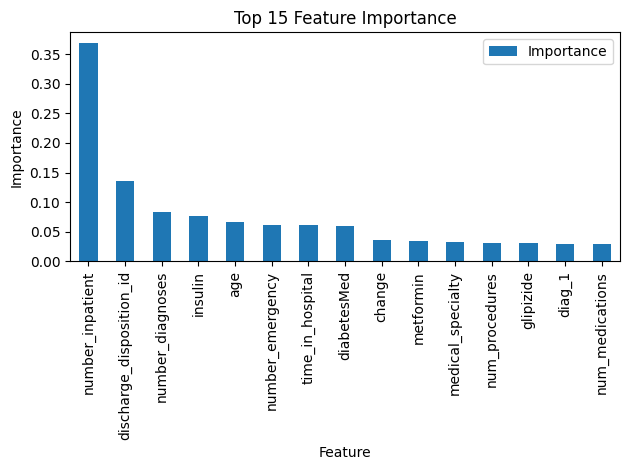

In [37]:
plt.figure(figsize=(12,6))

top_features.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title('Top 15 Feature Importance')
plt.ylabel('Importance')

plt.tight_layout()

plt.show()


In [38]:
import joblib

scaler = joblib.load("../models/scaler.pkl")
pca = joblib.load("../models/pca_95.pkl")
model = joblib.load("../models/hospital_readmission_model.pkl")

print("Scaler features:", scaler.n_features_in_)
print("PCA components:", pca.n_components_)

Scaler features: 41
PCA components: 35


In [40]:
print(X.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [19]:
X.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2,0,0,6,25,1,1,37,41,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,1,1,1,7,3,71,59,0,...,0,0,2,0,0,0,0,0,0,1
2,0,0,2,1,1,7,2,71,11,5,...,0,0,0,0,0,0,0,0,1,1
3,2,1,3,1,1,7,2,71,44,1,...,0,0,2,0,0,0,0,0,0,1
4,2,1,4,1,1,7,1,71,51,0,...,0,0,1,0,0,0,0,0,0,1
